# Basic Sequence to Sequence Translation


In [ ]:
import re, math, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from collections import Counter
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **k: x

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"
print("device:", device)

MAX_LEN      = 30      # train on pairs with <= MAX_LEN tokens on both sides
MIN_FREQ     = 5       # words rarer than this become <UNK>
MAX_VOCAB    = 30000
BATCH_SIZE   = 128
EPOCHS       = 8
LR           = 1e-3
CLIP         = 1.0
EMB_DIM      = 256
HID_DIM      = 512
N_LAYERS     = 2
DROPOUT      = 0.3
TRAIN_SUBSET = None    # set to e.g. 30000 to smoke-test the pipeline quickly
VAL_SUBSET   = 5000    # validate on a subset each epoch to save time
NUM_WORKERS  = 0       # data is pre-encoded so 0 is fine (avoids Windows pickling issues)

train = pd.read_csv("en_fr_train.csv").dropna().astype(str)
val   = pd.read_csv("en_fr_val.csv").dropna().astype(str)
test  = pd.read_csv("en_fr_test.csv").dropna().astype(str)

print(train.shape, val.shape, test.shape)
print(train.head())

c:\Users\shrey\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
(232825, 2) (890, 2) (8597, 2)
                                                  en  \
0  Thank you so much, Chris. And it's truly a gre...   
1  I have been blown away by this conference, and...   
2  And I say that sincerely, partly because  Put ...   
3           I flew on Air Force Two for eight years.   
4  Now I have to take off my shoes or boots to ge...   

                                                  fr  
0  Merci beaucoup, Chris. C'est vraiment un honne...  
1  J'ai été très impressionné par cette conférenc...  
2  Et je dis çà sincèrement, en autres parce que ...  
3       J'ai volé avec Air Force 2 pendant huit ans.  
4  Et maintenant, je dois enlever mes chaussures ...  


### Tokenisation
Punctuation is split off (`"much,"` -> `"much"`, `","`), so the vocab doesn't explode.
Pairs longer than `MAX_LEN` are **filtered out** instead of truncated.

In [2]:
def tokenize(s):
    return re.findall(r"\w+|[^\w\s]", str(s).lower())

for df in (train, val, test):
    df["en_tok"] = df["en"].map(tokenize)
    df["fr_tok"] = df["fr"].map(tokenize)

def length_filter(df, max_len=MAX_LEN):
    el = df["en_tok"].str.len()
    fl = df["fr_tok"].str.len()
    return df[(el >= 1) & (el <= max_len) & (fl >= 1) & (fl <= max_len)].reset_index(drop=True)

n_before = len(train)
train_f = length_filter(train)
val_f   = length_filter(val)
print(f"train kept {len(train_f)}/{n_before} ({len(train_f)/n_before:.1%}) | val kept {len(val_f)}/{len(val)}")

train kept 173533/232825 (74.5%) | val kept 623/890


In [ ]:
PAD, SOS, EOS, UNK = 0, 1, 2, 3
SPECIAL_TOKENS = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]

def build_vocab(token_lists, min_freq=MIN_FREQ, max_size=MAX_VOCAB):
    counter = Counter()

    for toks in token_lists:
        counter.update(toks)
    vocab = {t: i for i, t in enumerate(SPECIAL_TOKENS)}

    for w, c in counter.most_common(max_size):
        if c < min_freq:
            break
        vocab[w] = len(vocab) #new word has token of length of vocab

    return vocab

en_vocab = build_vocab(train_f["en_tok"])
fr_vocab = build_vocab(train_f["fr_tok"])
en_id_to_word = {i: w for w, i in en_vocab.items()}
fr_id_to_word = {i: w for w, i in fr_vocab.items()}

print("EN vocab:", len(en_vocab), "| FR vocab:", len(fr_vocab))

def encode_ids(tokens, vocab, max_len=MAX_LEN):
    return [SOS] + [vocab.get(t, UNK) for t in tokens[:max_len]] + [EOS]

print(encode_ids(tokenize("I am Shreyas"), en_vocab))
print([en_id_to_word[i] for i in encode_ids(tokenize("I am Shreyas"), en_vocab)])

EN vocab: 14609 | FR vocab: 17730
[1, 13, 259, 3, 2]
['<SOS>', 'i', 'am', '<UNK>', '<EOS>']


In [4]:
class TranslationDataset(Dataset):
    def __init__(self, en_toks, fr_toks):
        self.en = [encode_ids(t, en_vocab) for t in en_toks]
        self.fr = [encode_ids(t, fr_vocab) for t in fr_toks]
        self.lengths = np.array([max(len(a), len(b)) for a, b in zip(self.en, self.fr)])

    def __len__(self):
        return len(self.en)

    def __getitem__(self, i):
        return self.en[i], self.fr[i]


class BucketBatchSampler(Sampler):
    # shuffle, then sort by length inside big chunks, cut into batches, shuffle the batches
    def __init__(self, lengths, batch_size, shuffle=True, chunk_mult=50):
        self.lengths = np.asarray(lengths)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.chunk = batch_size * chunk_mult

    def __iter__(self):
        idx = np.arange(len(self.lengths))
        if self.shuffle:
            np.random.shuffle(idx)
        batches = []
        for i in range(0, len(idx), self.chunk):
            c = idx[i:i + self.chunk]
            c = c[np.argsort(self.lengths[c], kind="stable")]
            batches += [c[j:j + self.batch_size].tolist() for j in range(0, len(c), self.batch_size)]
        if self.shuffle:
            random.shuffle(batches)
        return iter(batches)

    def __len__(self):
        return math.ceil(len(self.lengths) / self.batch_size)


def collate(batch):
    # returns (seq_len, batch) tensors
    en = pad_sequence([torch.tensor(b[0]) for b in batch], padding_value=PAD)
    fr = pad_sequence([torch.tensor(b[1]) for b in batch], padding_value=PAD)
    return en, fr


train_df = train_f.sample(TRAIN_SUBSET, random_state=SEED).reset_index(drop=True) if TRAIN_SUBSET else train_f
val_df   = val_f.sample(min(VAL_SUBSET, len(val_f)), random_state=SEED).reset_index(drop=True) if VAL_SUBSET else val_f

train_dataset = TranslationDataset(train_df["en_tok"], train_df["fr_tok"])
val_dataset   = TranslationDataset(val_df["en_tok"], val_df["fr_tok"])

train_loader = DataLoader(
    train_dataset,
    batch_sampler=BucketBatchSampler(train_dataset.lengths, BATCH_SIZE, shuffle=True),
    collate_fn=collate, num_workers=NUM_WORKERS, pin_memory=use_amp,
)
val_loader = DataLoader(
    val_dataset,
    batch_sampler=BucketBatchSampler(val_dataset.lengths, BATCH_SIZE * 2, shuffle=False),
    collate_fn=collate, num_workers=NUM_WORKERS, pin_memory=use_amp,
)

en_batch, fr_batch = next(iter(train_loader))
print(en_batch.shape, fr_batch.shape, "| steps/epoch:", len(train_loader))

torch.Size([15, 128]) torch.Size([15, 128]) | steps/epoch: 1356


In [5]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(emb_dim, hid_dim, num_layers=n_layers,
                            dropout=dropout if n_layers > 1 else 0.0)

    def forward(self, src):                      # src: (S, B)
        lengths = (src != PAD).sum(0).cpu()
        emb = self.dropout(self.embedding(src))
        packed = pack_padded_sequence(emb, lengths, enforce_sorted=False)
        _, (hidden, cell) = self.lstm(packed)    # final states = context vector
        return hidden, cell


class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.output_dim = vocab_size
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(emb_dim, hid_dim, num_layers=n_layers,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.fc_out = nn.Linear(hid_dim, vocab_size)

    def forward(self, token, hidden, cell):      # one step: token (B,)
        emb = self.dropout(self.embedding(token.unsqueeze(0)))
        output, (hidden, cell) = self.lstm(emb, (hidden, cell))
        return self.fc_out(output.squeeze(0)), hidden, cell


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward_tf(self, src, trg):
        # full teacher forcing, whole decoder in one cuDNN call
        # input trg[:-1] -> predicts trg[1:], output shape (T-1, B, V)
        hidden, cell = self.encoder(src)
        emb = self.decoder.dropout(self.decoder.embedding(trg[:-1]))
        out, _ = self.decoder.lstm(emb, (hidden, cell))
        return self.decoder.fc_out(out)

    @torch.no_grad()
    def greedy_decode(self, src, max_len=80):
        # free-running decoding, no target needed. returns (B, <=max_len) token ids on cpu
        hidden, cell = self.encoder(src)
        B = src.shape[1]
        token = torch.full((B,), SOS, dtype=torch.long, device=src.device)
        finished = torch.zeros(B, dtype=torch.bool, device=src.device)
        outs = []
        for _ in range(max_len):
            logits, hidden, cell = self.decoder(token, hidden, cell)
            token = logits.argmax(1)
            outs.append(token)
            finished |= token == EOS
            if finished.all():
                break
        return torch.stack(outs, 1).cpu()


encoder = Encoder(len(en_vocab), EMB_DIM, HID_DIM, N_LAYERS, DROPOUT)
decoder = Decoder(len(fr_vocab), EMB_DIM, HID_DIM, N_LAYERS, DROPOUT)
model = Seq2Seq(encoder, decoder).to(device)

print(f"parameters: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

parameters: 24.7M


### Training
Mixed precision, gradient clipping, LR decay on plateau, checkpoint every epoch (best val loss kept in `best_model.pt`).
Tip: set `TRAIN_SUBSET = 30000` and `EPOCHS = 2` in the config cell first to check that the loss goes down.

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=1) #stops lowering lr when val loss stops improving
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

torch.save({"en_vocab": en_vocab, "fr_vocab": fr_vocab}, "vocab.pt")


def run_epoch(loader, train_mode):
    model.train(train_mode)
    total, n = 0.0, 0
    for src, trg in tqdm(loader, leave=False):
        src = src.to(device, non_blocking=True)
        trg = trg.to(device, non_blocking=True)
        with torch.set_grad_enabled(train_mode):
            with torch.autocast(device_type=device.type, enabled=use_amp):
                out = model.forward_tf(src, trg)                     # (T-1, B, V)
                loss = criterion(out.reshape(-1, out.shape[-1]), trg[1:].reshape(-1))
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), CLIP)
                scaler.step(optimizer)
                scaler.update()
        total += loss.item()
        n += 1
    return total / n


train_losses, val_losses = [], []
best_val = float("inf")

for epoch in range(EPOCHS):
    t0 = time.time()
    tr = run_epoch(train_loader, True)
    va = run_epoch(val_loader, False)
    scheduler.step(va)
    train_losses.append(tr)
    val_losses.append(va)

    torch.save({"model": model.state_dict(), "opt": optimizer.state_dict(), "epoch": epoch}, "last_ckpt.pt")
    if va < best_val:
        best_val = va
        torch.save(model.state_dict(), "best_model.pt")

    print(f"Epoch {epoch+1}/{EPOCHS} | {time.time()-t0:.0f}s | "
          f"train {tr:.3f} (ppl {math.exp(tr):.1f}) | val {va:.3f} (ppl {math.exp(va):.1f})"
          f"{'  <- best' if va == best_val else ''}")

Epoch 1/8 | 60s | train 4.288 (ppl 72.8) | val 3.683 (ppl 39.8)  <- best


Epoch 2/8 | 56s | train 3.269 (ppl 26.3) | val 3.325 (ppl 27.8)  <- best


Epoch 3/8 | 55s | train 2.929 (ppl 18.7) | val 3.138 (ppl 23.1)  <- best


Epoch 4/8 | 56s | train 2.699 (ppl 14.9) | val 3.015 (ppl 20.4)  <- best


Epoch 5/8 | 55s | train 2.525 (ppl 12.5) | val 2.940 (ppl 18.9)  <- best


Epoch 6/8 | 56s | train 2.381 (ppl 10.8) | val 2.879 (ppl 17.8)  <- best


Epoch 7/8 | 55s | train 2.260 (ppl 9.6) | val 2.835 (ppl 17.0)  <- best


Epoch 8/8 | 56s | train 2.157 (ppl 8.6) | val 2.802 (ppl 16.5)  <- best


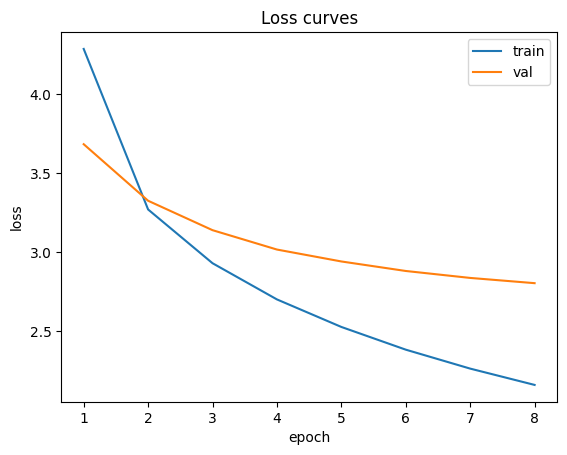

In [7]:
plt.plot(range(1, len(train_losses) + 1), train_losses, label="train")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Loss curves")
plt.show()

## Evaluation (BLEU on the test split)
Greedy decoding, batched. BLEU is computed on tokens produced by the same tokenizer for hypothesis and reference
(so it is not directly comparable to sacreBLEU numbers).
Test sentences are **not** filtered to 30 tokens, so long-sentence behaviour is visible.

In [8]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()

EVAL_MAX_SRC = 60 # skip very long test sentences
TEST_LIMIT   = None

test_e = test[(test["en_tok"].str.len() >= 1) & (test["en_tok"].str.len() <= EVAL_MAX_SRC)].reset_index(drop=True)
if TEST_LIMIT:
    test_e = test_e.sample(min(TEST_LIMIT, len(test_e)), random_state=SEED).reset_index(drop=True)
print("test sentences:", len(test_e))


def translate_batch(token_lists, bs=256, max_len=80):
    enc = [encode_ids(t, en_vocab, max_len=EVAL_MAX_SRC) for t in token_lists]
    order = np.argsort([len(e) for e in enc])
    results = [None] * len(enc)
    for i in tqdm(range(0, len(order), bs), leave=False):
        idx = order[i:i + bs]
        src = pad_sequence([torch.tensor(enc[j]) for j in idx], padding_value=PAD).to(device)
        out = model.greedy_decode(src, max_len=max_len)
        for k, j in enumerate(idx):
            words = []
            for t in out[k].tolist():
                if t == EOS:
                    break
                words.append(fr_id_to_word[t])
            results[j] = words
    return results


t0 = time.time()
hyps = translate_batch(list(test_e["en_tok"]))
refs = [[r] for r in test_e["fr_tok"]]
print(f"decoded in {time.time()-t0:.0f}s")

smooth = SmoothingFunction().method1
bleu = corpus_bleu(refs, hyps, smoothing_function=smooth)
print(f"Test BLEU: {bleu*100:.2f}")

test sentences: 8466


decoded in 3s
Test BLEU: 11.73


src length    n  BLEU  hyp/ref length
      1-10 2046 22.04            0.94
     11-20 3238 14.86            0.96
     21-30 1783 10.21            0.94
     31-60 1399  7.51            0.90


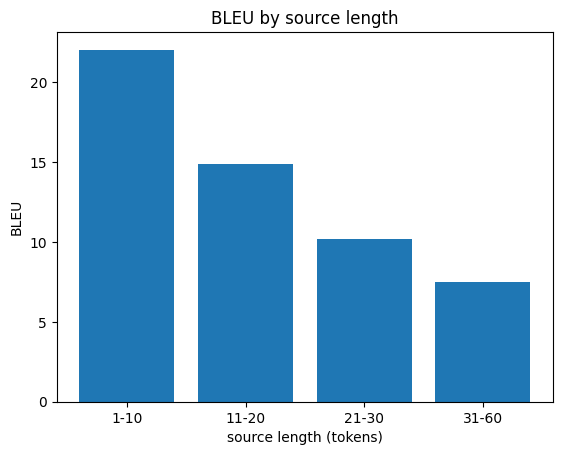

In [9]:
# 1) BLEU and output length ratio by source length
test_e["src_len"] = test_e["en_tok"].str.len()
test_e["hyp"] = hyps
bins   = [0, 10, 20, 30, EVAL_MAX_SRC]
labels = ["1-10", "11-20", "21-30", f"31-{EVAL_MAX_SRC}"]
test_e["bucket"] = pd.cut(test_e["src_len"], bins=bins, labels=labels)

def bleu_of(sub):
    if len(sub) == 0:
        return float("nan")
    r = [[x] for x in sub["fr_tok"]]
    return corpus_bleu(r, list(sub["hyp"]), smoothing_function=smooth) * 100

rows = []
for lab in labels:
    sub = test_e[test_e["bucket"] == lab]
    ratio = (sub["hyp"].str.len().sum() / max(sub["fr_tok"].str.len().sum(), 1)) if len(sub) else float("nan")
    rows.append({"src length": lab, "n": len(sub), "BLEU": round(bleu_of(sub), 2), "hyp/ref length": round(ratio, 2)})
bucket_table = pd.DataFrame(rows)
print(bucket_table.to_string(index=False))

plt.bar(bucket_table["src length"], bucket_table["BLEU"])
plt.xlabel("source length (tokens)"); plt.ylabel("BLEU"); plt.title("BLEU by source length")
plt.show()

So the model performs very bad when sentences go above 20 words but performs okayish on basic sentences of less than 10-15 words so obviously this isn't a model which we would practically use for translation